Anteriormente estudiamos como en un problema de Regresión Lineal podemos obtener los coeficientes que minimizan la función de perdida usando el metodo de minimos cuadrados. 
Este método es util cuando tenemos funciones de perdida convexas y con un punto minimo global, pero qué es lo que sucede cuando tenemos funciones que tienen más de un punto minimo?

<img src="minimolocalglobal.png">

El método del descenso del gradiente es un algoritmo de optimización utilizado para encontrar el mínimo de una función, especialmente en el contexto de problemas de optimización en el aprendizaje automático y la inteligencia artificial. Este método es fundamental en la optimización de modelos en machine learning, donde el objetivo es ajustar los parámetros del modelo para minimizar una función de pérdida o error. Este método de optimización es util cuando tenemos funciones de perdida que no son convexas.

### EJEMPLO DE UNA FUNCION DE PERDIDA EN R3

<img src="minimoslocalesr3.png">

La idea principal detrás del descenso del gradiente es iterativamente ajustar los parámetros de nuestro modelo en la dirección opuesta al gradiente de la función de pérdida en un punto dado. Este punto de partida lo podemos escoger nosotros o seleccionarlo al azar . Recordemos que el gradiente es un vector que indica la dirección y la magnitud del cambio máximo de la función en ese punto. Al moverse en la dirección opuesta al gradiente, el algoritmo busca encontrar el mínimo de la función.

El procedimiento del descenso del gradiente se puede describir en los siguientes pasos:

1.- Inicialización de parámetros: Se comienza con un conjunto inicial de parámetros.

2.-Cálculo del gradiente: Se calcula el gradiente de la función de pérdida con respecto a los parámetros actuales. El gradiente indica la dirección en la cual la función de pérdida aumenta más rápidamente.

3.- Actualización de parámetros: Se ajustan los parámetros en la dirección opuesta al gradiente multiplicado por una tasa de aprendizaje. La tasa de aprendizaje controla el tamaño de los pasos que se dan en cada iteración. Es importante encontrar un equilibrio, ya que una tasa de aprendizaje demasiado pequeña puede hacer que el algoritmo sea lento, mientras que una tasa de aprendizaje demasiado grande puede hacer que el algoritmo diverja o no converja correctamente.

4.- Iteración: Se repiten los pasos 2 y 3 hasta que se alcanza un criterio de convergencia, como un número fijo de iteraciones o cuando el cambio en la función de pérdida es lo suficientemente pequeño.

Este proceso se repite hasta que se alcanza un mínimo local o se aproxima al mínimo global de la función de pérdida.







Recordemos que El gradiente de una función 
$ f\ $, que se denota como 
$ \nabla f $
es la colección de todas las derivadas parciales en forma de vector.


Formalmente, si comenzamos en un punto 
$ x_0$  y nos movemos una distancia positiva 
$ \alpha$  en la dirección del gradiente negativo, entonces nuestro nuevo y mejorado 
$ x_1$  se verá así:
$$ x_1 = x_0 - \alpha \nabla f(x_0) $$ 
Más generalmente, podemos escribir una fórmula para convertir 
$ x_n$  en 
$ x_{n + 1}$ :
$$ x_{n + 1} = x_n - \alpha \nabla f(x_n)$$ 
A partir de una conjetura inicial 
$ x_0$ , la seguimos mejorando poco a poco hasta encontrar un mínimo local.
$ \alpha $ es conocido como "tasa de aprendizaje" 

### IMPLEMENTACIÓN DEL ALGORITMO DEL DESCENSO DEL GRADIENTE

In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import random

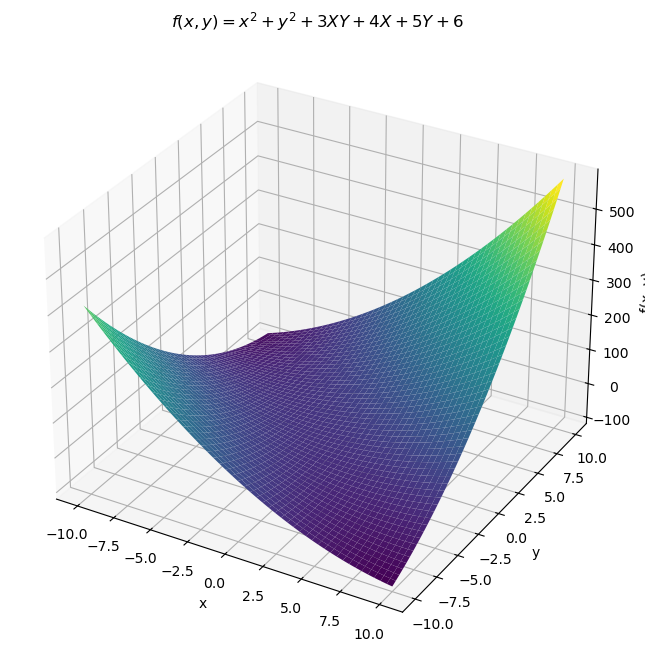

In [3]:
def func(x, y):
    return x**2 + y**2 + 3*x*y + 4*x + 5*y + 6


# Crear una cuadrícula de puntos
x_vals = np.linspace(-10, 10, 400)
y_vals = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = func(X, Y)

# Crear la figura y el eje 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficar la superficie
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

# Añadir etiquetas y título
ax.set_title('$f(x, y) = x^2 + y^2 +3XY +4X + 5Y +6$')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')

# Mostrar la gráfica
plt.show()

[array([-0.50183952,  1.80285723])]
-9.346231104593533 7.546242624941542


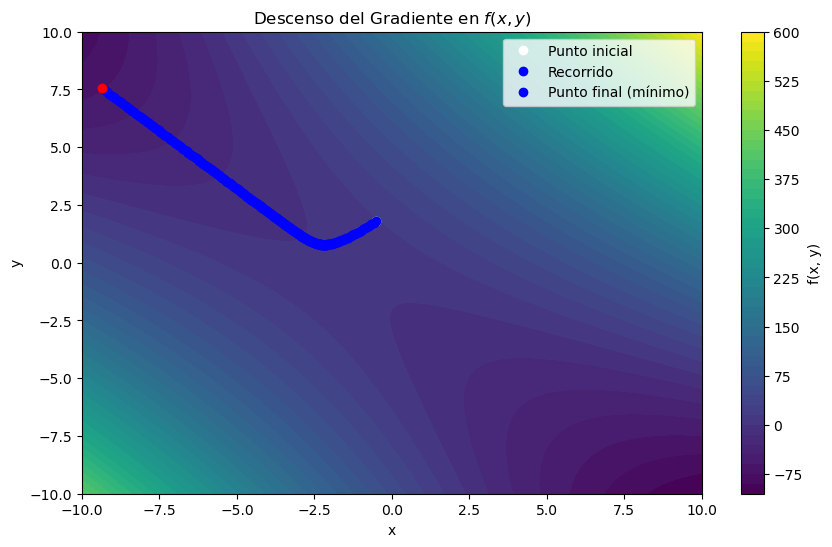

In [4]:
# Definir la función f
def func(vect):
    x, y = vect
    return x**2 + y**2 + 3*x*y + 4*x + 5*y + 6


# Definir el gradiente de f
def grad_func(vect):
    x, y = vect
    df_dx = 2*x + 3*y + 4
    df_dy = 2*y + 3*x + 5


    return np.array([df_dx, df_dy])

# Parámetros de descenso del gradiente
lr = 0.0001
num_iterations = 25000

# Inicialización
np.random.seed(42)  # Para reproducibilidad
T = np.random.rand(2) * 4 - 2  # Punto inicial aleatorio en el rango [-2, 2]

# Guardar puntos para graficar
points = [T.copy()]
print(points)

# Crear una cuadrícula de puntos para graficar la función
x_vals = np.linspace(-10, 10, 400)
y_vals = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = np.array([func([x, y]) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

# Graficar la función f
plt.figure(figsize=(10, 6))
plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(label='f(x, y)')

# Graficar el punto inicial
plt.plot(T[0], T[1], 'o', c='white')

# Descenso del gradiente
for aux in range(num_iterations):
    gradiente = grad_func(T)
    T = T - lr * gradiente
    points.append(T.copy())
    
    if aux % 100 == 0:  # Graficar el punto cada 100 iteraciones
        plt.plot(T[0], T[1], 'o', c='blue')

# Graficar el punto final
plt.plot(T[0], T[1], 'o', c='red')
print(T[0], T[1])
# Etiquetas y leyenda
plt.title('Descenso del Gradiente en $f(x, y)$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(['Punto inicial', 'Recorrido', 'Punto final (mínimo)'])

plt.show()

#### ¿Cómo podemos hacer descenso del gradiente sin calcular exactamente las derivadas parciales de la funcion?

Fuente Dot CSV
https://www.youtube.com/watch?v=-_A_AAxqzCg&t=1201s

In [4]:
#### DEFINIMOS UNA FUNCION DE PERDIDA
def func(vect):
    return np.sin(1/2 * vect[0]**2 -1/4 * vect[1] **2 +3) * np.cos(2 * vect[0] +1 - np.e **vect[1])

<img src="funcionperdidagradiente.png">

In [5]:
func([2,2])

0.5524336596433619

In [6]:
long= 100
X = np.linspace(-2,2,long) ## 100 valores entre menos 2 y 2
Y = np.linspace(-2,2,long) ## 100 valores entre menos 2 y 2
Z = np.zeros((long,long))

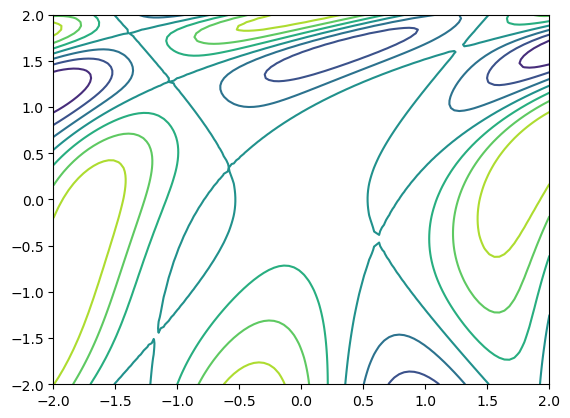

In [8]:
plt.contour(X,Y,Z) ### visualizamos la funcion desde arriba (Curvas de nivel)
plt.show()

[1, 0]


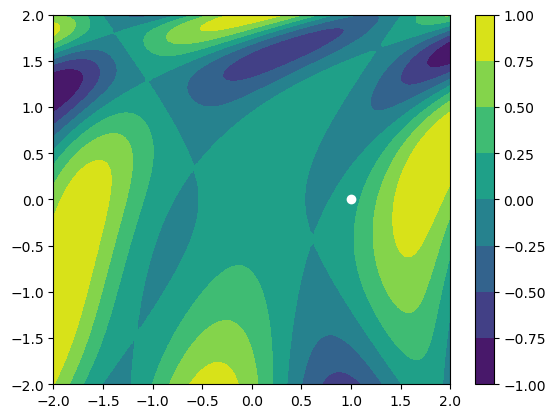

In [9]:
plt.contourf(X,Y,Z) ### visualizamos de otra forma, los colores muestran la profundidad y altura de la funcion
plt.colorbar() ### mas oscuro mas profundo
T = random.sample(range(-2, 2),2) # generamos dos numeros aleatorios dentro de -2 y 2
print(T)
plt.plot(T[0],T[1],"o",c="white")
plt.show() 

[1, 0]
0.14597733051683126
0.14482115771664297
0.14367205102718278
0.14252998201675884
0.14139492206630466
0.14026684237621878
0.1391457139731074
0.13803150771644668
0.13692419430514202
0.13582374428399965
0.134730128050095
0.133643315859059
0.13256327783128014
0.1314899839579847
0.130423404107253
0.12936350802993585
0.12831026536547538
0.12726364564764248
0.12622361831017667
0.12519015269233577
0.12416321804437377
0.12314278353290356
0.12212881824619115
0.12112129119935659
0.12012017133948262
0.11912542755064087
0.1181370286588361
0.11715494343686493
0.11617914060907665
0.11520958885606399
0.11424625681926846
0.11328911310550252
0.1123381262913782
0.1113932649276719
0.11045449754360498
0.1095217926510312
0.10859511874855898
0.10767444432558732
0.10675973786627373
0.10585096785340911
0.10494810277223311
0.1040511111141636
0.10315996138045379
0.10227462208578046
0.10139506176174866
0.10052124896033851
0.09965315225726296
0.09879074025527007
0.09793398158737038
0.09708284491998799
0.0962

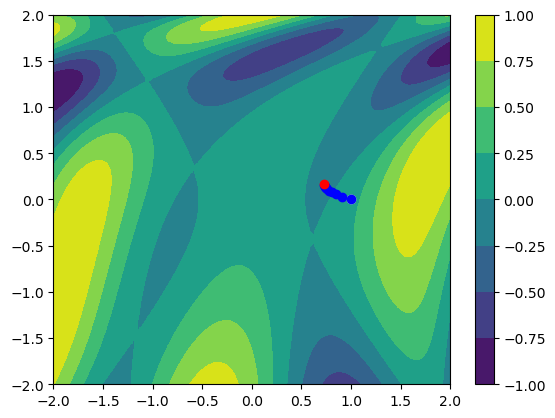

In [10]:
plt.contourf(X,Y,Z) ### visualizamos de otra forma, los colores muestran la profundidad y altura de la funcion
plt.colorbar() ### mas oscuro mas profundo
#T = random.sample(range(-2, 2),2) # generamos dos numeros aleatorios dentro de -2 y 2
print(T)

T_ =np.copy(T) ### creamos una copia del vector

gradiente = np.zeros(2)

h= .0001

lr = .001

plt.plot(T[0],T[1],"o",c="white")

for aux in range(1000):

    for it,t in enumerate(T): 
        ### interpretemos las derivadas como "que tanto varía la salida de esta funcion al incrementar ligeramente la entrada de la funcion"
        ### recordemos que la derivada  de una función nos indica el ritmo con el que una función varía
        #, es decir, crece, decrece cuando se producen pequeños cambios en la variable X
        
        T_= np.copy(T)

        T_[it] =  T_[it] + h
        derivada = (func(T_) - func(T)) / h #### definicion formal de derivada 
        gradiente[it] = derivada   #### este bucle hace las derivadas parciales

    T = T - lr * gradiente
    print(func(T)) #### al incrementar el valor de lr los valores tendrán una razon de cambio mayor
    
    if aux % 100 ==0: ### hacemos esto para ver el recorrido cada 100 iteraciones
        plt.plot(T[0],T[1],"o",c="blue")
        
    
    

plt.plot(T[0],T[1],"o",c="red")
plt.show() 

<img src="derivada.png">

la tasa de aprendizaje es un parametro del modelo que no depende directamente de los datos. Nosotros como desarrolladores
tenemos la tarea de ajustarlo correctamente. A este tipo de parametros que son exclusivos del modelo se les llama hiperparametros

que pasa si escogemos un lr muy alto?

https://www.benfrederickson.com/numerical-optimization/

alcanzamos el minimo global?

CONCLUSIÓN:
El metodo del descenso del gradiente es un metodo de optimización util cuando nuestra función de perdida tiene varios puntos minimos

Para utilizar este metodo necesitamos una función de perdida y ajustar correctamente el hiperparametro de tasa de aprendizaje ( de este dependerá la convergencia el algoritmo)

para entender mejor el concepto de gradiente consultar:
    https://es.khanacademy.org/math/multivariable-calculus/multivariable-derivatives/partial-derivative-and-gradient-articles/a/the-gradient